# Calderon's Problem PlayGround

## Direct problem - forward finite differences solver

In [1]:
# filename: codebase/fdm_forward_solver.py
import os
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

### Generate the data

In [2]:
class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE nabla . (gamma * nabla u) = 0 on a
    square domain [0, 1] x [0, 1] with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        """
        Initializes the FDM solver.

        Args:
            N (int): The number of grid points in each dimension.
        """
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        """
        Identifies boundary nodes, coordinates, and normal vectors.

        Returns:
            dict: A dictionary containing:
                'indices': 1D indices of boundary nodes.
                'coords': (x, y) coordinates of boundary nodes.
                'normals': (nx, ny) normal vectors for each boundary node.
        """
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:  # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:  # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    # Normalize the normal vector in case of corners
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        # Ensure unique nodes for corners
        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
        
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }


    def _assemble_system(self, gamma):
        """
        Assembles the sparse matrix A for the linear system Au=b.

        Args:
            gamma (np.ndarray): A N x N array of conductivity values.

        Returns:
            scipy.sparse.csc_matrix: The assembled sparse matrix A.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for conductivity at interfaces
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1] = gamma_E / h2  # East
                A[p, p - 1] = gamma_W / h2  # West
                A[p, p + self.N] = gamma_N / h2  # North
                A[p, p - self.N] = gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solves the forward problem for a given gamma and boundary conditions.

        Args:
            gamma (np.ndarray): The N x N conductivity map.
            boundary_values (dict): A dictionary mapping 1D boundary indices
                                    to potential values.

        Returns:
            np.ndarray: A N x N array of the potential u.
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        # Apply Dirichlet boundary conditions
        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Computes the normal current density J = gamma * du/dn on the boundary.

        Args:
            u (np.ndarray): The N x N potential field.
            gamma (np.ndarray): The N x N conductivity map.

        Returns:
            np.ndarray: A 1D array of normal current densities at boundary points.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
        
        J = np.zeros(len(bnd_indices))
        
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
                
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
                
                # Compute gradients using second-order one-sided differences
                du_dx = 0.0
                du_dy = 0.0

                # Gradient in x
                if j == 0:  # Left boundary, forward difference
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right boundary, backward difference
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else: # Interior point for x-gradient (corners on y-boundary)
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                # Gradient in y
                if i == 0:  # Bottom boundary, forward difference
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top boundary, backward difference
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else: # Interior point for y-gradient (corners on x-boundary)
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
                
        return J









############TRYING NEW CONSTRAINING C TO BE POSITIVE##########

# gamma_utils.py
import numpy as np

def enforce_l1_ball(c_raw, B=None, gamma0=1.0, eps=0.05):
    """
    Scale c_raw so that sum_i B_i |c_i| <= R where R = gamma0 - eps.
    B=None => all B_i = 1 (cos/sin basis on [0,1]^2).
    """
    c_raw = np.asarray(c_raw, float)
    if B is None:
        B = np.ones_like(c_raw)
    R = gamma0 - eps
    w_l1 = np.sum(B * np.abs(c_raw))
    if w_l1 <= R or R <= 0:
        return c_raw.copy()
    scale = R / w_l1
    return scale * c_raw

def fourier_gamma_on_grid(N, c, k_list, Lx=1.0, Ly=1.0,
                          include_cos=True, include_sin=True,
                          background=1.0):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    gamma = np.full((N, N), background, float)
    idx = 0
    for (kx, ky) in k_list:
        phase = 2.0*np.pi*(kx*xx/Lx + ky*yy/Ly)
        if include_cos:
            gamma += c[idx] * np.cos(phase); idx += 1
        if include_sin:
            gamma += c[idx] * np.sin(phase); idx += 1
    return gamma


def get_gamma_fourier_linear_L1(N, gamma_param):
    """
    Build gamma linearly from Fourier coefficients AFTER enforcing the L1-ball.
    Keeps gamma linear in c and guarantees gamma >= eps by design (no softplus).
    """
    k_list      = gamma_param['k_list']
    include_cos = bool(gamma_param.get('include_cos', True))
    include_sin = bool(gamma_param.get('include_sin', True))
    Lx          = float(gamma_param.get('Lx', 1.0))
    Ly          = float(gamma_param.get('Ly', 1.0))
    background  = float(gamma_param.get('background', 1.0))
    gamma0      = background
    eps         = float(gamma_param.get('eps', 0.05))   # you can add this to your dict
    c_raw       = np.asarray(gamma_param['c'], dtype=float)

    # Enforce sum|c| <= gamma0 - eps  (B=1 for cos/sin)
    c_safe = enforce_l1_ball(c_raw, B=None, gamma0=gamma0, eps=eps)

    # Build gamma on grid using the same basis ordering
    gamma = fourier_gamma_on_grid(
        N, c_safe, k_list, Lx=Lx, Ly=Ly,
        include_cos=include_cos, include_sin=include_sin,
        background=background
    )
    return gamma, c_safe

###########################################################

###########TRYING NEW GAMMA HERE###############


# def get_gamma_fourier_parametric(N, gamma_param=None):
#     """
#     Parametric Fourier gamma on [0,1]x[0,1].

#     Uses basis (per k in k_list): [cos, sin] when include_* = True.
#     Phase uses 2*pi*(kx*x/Lx + ky*y/Ly) so that k=1 is one full wave across Lx/Ly.
#     """
#     # Default to your requested configuration if none is provided
#     if gamma_param is None:
#         # gamma_param = {
#         #     'k_list': [(1, 0), (0, 1), (1, 1)],
#         #     'Lx': 1.0, 'Ly': 1.0,
#         #     'include_cos': True,
#         #     'include_sin': True,
#         #     'c': [0.40, -0.20, 0.30, 0.15, 0.10, 0.00],  # matches [cos, sin] per k in order
#         #     'background': 1.0,
#         #     # Optional positivity controls (uncomment or pass in):
#         #     # 'positivity': 'none',  # 'none' | 'softplus' | 'sigmoid_bounds'
#         #     # 'min_gamma': 0.1, 'max_gamma': 5.0
#         # }
        
#         gamma_param = {
#             'k_list': [(1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 2), (1,2), (2,1)],
#             'Lx': 1.0, 'Ly': 1.0,
#             'include_cos': True,
#             'include_sin': True,
#             'c': [0.40, -0.20, 0.30, 0.15, 0.10, 0.40,0.9, 0.55, 3.25, 5.00, 1.87, -3.21, -6.98, 1.23, -4.50, 2.69],  # 16 coeffs -> matches 16 basis functions
#             'background': 1.0,
#             'positivity': 'softplus',  # or 'softplus' / 'sigmoid_bounds' (+ min/max)
#             # 'min_gamma': 0.5, 'max_gamma': 2.5,        # if you pick 'sigmoid_bounds'
#     }

#     k_list      = gamma_param['k_list']
#     Lx          = float(gamma_param.get('Lx', 1.0))
#     Ly          = float(gamma_param.get('Ly', 1.0))
#     include_cos = bool(gamma_param.get('include_cos', True))
#     include_sin = bool(gamma_param.get('include_sin', True))
#     coeffs      = np.asarray(gamma_param['c'], dtype=float)
#     background  = float(gamma_param.get('background', 1.0))

#     # Build basis order to validate coefficient count
#     basis = []
#     for (kx, ky) in k_list:
#         if include_cos: basis.append(('cos', kx, ky))
#         if include_sin: basis.append(('sin', kx, ky))
#     if len(coeffs) != len(basis):
#         raise ValueError(
#             f"Coefficient count ({len(coeffs)}) must match number of active basis functions ({len(basis)}). "
#             f"Active basis in order: {basis}"
#         )

#     # Grid
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)

#     # Assemble gamma = background + Fourier sum
#     gamma = np.full((N, N), background, dtype=float)
#     ci = 0
#     for (kx, ky) in k_list:
#         phase = 2.0 * np.pi * (kx * xx / Lx + ky * yy / Ly)
#         if include_cos:
#             gamma += coeffs[ci] * np.cos(phase); ci += 1
#         if include_sin:
#             gamma += coeffs[ci] * np.sin(phase); ci += 1

#     # Optional positivity mapping (kept compatible with your prior pattern)
#     positivity = gamma_param.get('positivity', 'none')
#     if positivity == 'softplus':
#         gamma = np.log1p(np.exp(gamma))  # strictly positive
#     elif positivity == 'sigmoid_bounds':
#         min_g = float(gamma_param.get('min_gamma', 0.1))
#         max_g = float(gamma_param.get('max_gamma', 5.0))
#         gamma = min_g + (max_g - min_g) / (1.0 + np.exp(-gamma))

#     return gamma
############END NEW GAMMA HERE###############

def generate_dtn_data(case_name, gamma_true, N, K, saving_path=None):
    """
    Generates and saves the DtN map data for a given conductivity.
    """
    print("--- Starting data generation for case: " + case_name + " ---")
    
    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info['indices']
    bnd_coords = bnd_info['coords']

    # Define K=32 boundary conditions
    freq_pairs = [(1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 1), (1, 2), (2, 2),
                  (3, 0), (0, 3), (3, 1), (1, 3), (3, 2), (2, 3), (3, 3), (4, 0)]
    
    boundary_potentials = []
    clean_currents = []
    induced_potentials = []

    start_time = time.time()
    for k in range(K):
        m, n = freq_pairs[k // 2]
        is_sin = k % 2 == 1
        
        # Define boundary function f_k
        if is_sin:
            f_k = np.sin(m * np.pi * bnd_coords[:, 0] + n * np.pi * bnd_coords[:, 1])
        else:
            f_k = np.cos(m * np.pi * bnd_coords[:, 0] + n * np.pi * bnd_coords[:, 1])
        
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        
        # Solve for potential u_k
        u_k = solver.solve(gamma_true, boundary_values)
        
        # Compute normal current J_k
        J_k = solver.compute_normal_current(u_k, gamma_true)
        
        boundary_potentials.append(f_k)
        clean_currents.append(J_k)
        induced_potentials.append(u_k)
        
        if (k + 1) % 8 == 0:
            print("Generated data for " + str(k + 1) + "/" + str(K) + " boundary conditions...")

    boundary_potentials = np.array(boundary_potentials)
    clean_currents = np.array(clean_currents)
    
    # Add noise
    # noise_levels = [0.01, 0.05]
    # noisy_currents = {}
    
    # currents_norm = np.linalg.norm(clean_currents)
    # if currents_norm == 0:
    #     print("Warning: Norm of clean currents is zero. Cannot add relative noise.")
    #     # Handle case with zero norm to avoid division by zero
    #     for level in noise_levels:
    #         key = 'noise_' + str(int(level*100)) + 'pct'
    #         noisy_currents[key] = clean_currents.copy()
    # else:
    #     for level in noise_levels:
    #         noise = np.random.normal(0, 1, clean_currents.shape)
    #         noise_norm = np.linalg.norm(noise)
    #         scaled_noise = noise * (level * currents_norm / noise_norm)
    #         key = 'noise_' + str(int(level*100)) + 'pct'
    #         noisy_currents[key] = clean_currents + scaled_noise

    # Save data
    if saving_path is None:
        data_folder = "data_pablo_trial"
    else:
        data_folder = saving_path
        
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
    
    filename = os.path.join(data_folder, "dtn_data_" + case_name + ".npz")
    np.savez_compressed(
        filename,
        gamma_true=gamma_true,
        boundary_coords=bnd_coords,
        boundary_potentials=boundary_potentials,
        clean_currents=clean_currents,
        induced_potentials=induced_potentials,
        # noisy_currents_1pct=noisy_currents.get('noise_1pct', clean_currents),
        # noisy_currents_5pct=noisy_currents.get('noise_5pct', clean_currents),
        grid_N=N,
        num_bcs=K
    )
    
    end_time = time.time()
    print("Data generation for " + case_name + " complete. Time elapsed: " + str(round(end_time - start_time, 2)) + "s")
    print("Dataset saved to " + filename)
    
    # Print statistics
    print("\n--- Dataset Statistics (" + case_name + ") ---")
    print("FDM Grid Size: " + str(N) + "x" + str(N))
    print("Number of Boundary Functions (K): " + str(K))
    print("Boundary Points per Function: " + str(bnd_coords.shape[0]))
    print("Min/Max of Boundary Potential (f_k): " + str(round(np.min(boundary_potentials), 2)) + " / " + str(round(np.max(boundary_potentials), 2)))
    print("Mean of Clean Current Density (J_k): " + str(round(np.mean(clean_currents), 4)))
    print("Std. Dev. of Clean Current Density (J_k): " + str(round(np.std(clean_currents), 2)))
    print("Min/Max of Clean Current Density (J_k): " + str(round(np.min(clean_currents), 2)) + " / " + str(round(np.max(clean_currents), 2)))
    
    # Return one example for plotting
    example_u = solver.solve(gamma_true, {idx: val for idx, val in zip(bnd_indices, boundary_potentials[0])})
    return filename, example_u, boundary_potentials[0], clean_currents[0]




In [3]:

# def main(N,K, saving_path=None):
#     """Main function to generate all datasets and plots."""
#     N = N  # Grid size
#     K = K   # Number of boundary conditions
#     if saving_path is None:
#         saving_path = "data"
    
#     cases = {
#         "fourier_parametric": get_gamma_fourier_parametric(N),
#         # "single_inclusion": get_gamma_single_inclusion(N),
#         # "gaussian_inclusion": get_gamma_gaussian(N),
#         #"radially_sym_sine": get_gamma_radial_sine(N),
#         # "multiple_inclusions": get_gamma_multiple_inclusions(N),
#         # "checkerboard": get_gamma_checkerboard(N)
#     }

def main(N, K, saving_path=None):
    if saving_path is None:
        saving_path = "data"

    gamma_param = {
        'k_list': [(1,0),(0,1),(1,1),(2,0),(0,2),(2,2),(1,2),(2,1)],
        'Lx': 1.0, 'Ly': 1.0,
        'include_cos': True, 'include_sin': True,
        'c': [0.40, -0.20, 0.30, 0.15, 0.10, 0.40, 0.90, 0.55,
              3.25, 5.00, 1.87, -3.21, -6.98, 1.23, -4.50, 2.69],
        'background': 1.0,
        'eps': 0.05,               # <- margin for positivity
    }

    gamma_fourier, c_safe = get_gamma_fourier_linear_L1(N, gamma_param)
    print("L1(c_safe) =", np.sum(np.abs(c_safe)), " <= ", gamma_param['background'] - gamma_param['eps'])

        # (optional) save the exact c used alongside the dataset
    os.makedirs(saving_path, exist_ok=True)
    np.save(os.path.join(saving_path, "fourier_linear_L1_c_used.npy"), c_safe)
    with open(os.path.join(saving_path, "fourier_linear_L1_c_used.txt"), "w") as f:
        f.write(", ".join(f"{v:.8g}" for v in c_safe))
    
    cases = {
        "fourier_linear_L1": gamma_fourier,
        # "radially_sym_sine": get_gamma_radial_sine(N),
        # ...
    }
    
    for name, gamma_true in cases.items():
        filepath, u_ex, f_ex, J_ex = generate_dtn_data(name, gamma_true, N, K, saving_path=saving_path)
        
        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Ground Truth Gamma
        im0 = axes[0].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
        axes[0].set_title("Ground Truth Conductivity (gamma)")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")
        fig.colorbar(im0, ax=axes[0], orientation='vertical')
        
        # Plot 2: Example Potential Solution u_k
        im1 = axes[1].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[1].set_title("Example Potential Field u_0(x,y)")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        fig.colorbar(im1, ax=axes[1], orientation='vertical')
        
        # Plot 3: Example DtN data pair (f_k, J_k)
        bnd_info = FDMForwardSolver(N).boundary_info
        bnd_coords = bnd_info['coords']
        # Create a perimeter-like coordinate for plotting
        perimeter = np.zeros(len(bnd_coords))
        for i in range(1, len(bnd_coords)):
            perimeter[i] = perimeter[i-1] + np.linalg.norm(bnd_coords[i] - bnd_coords[i-1])
        
        axes[2].plot(perimeter, f_ex, 'b-', label='Potential f_0')
        ax2_twin = axes[2].twinx()
        ax2_twin.plot(perimeter, J_ex, 'r-', label='Current J_0')
        axes[2].set_title("Example DtN Pair on Boundary")
        axes[2].set_xlabel("Perimeter along Boundary")
        axes[2].set_ylabel("Potential (V)", color='b')
        ax2_twin.set_ylabel("Current Density (A/m^2)", color='r')
        axes[2].grid(True)
        
        fig.tight_layout()
        
        plot_filename = os.path.join("data", "plot_summary_" + name + "_" + str(int(time.time())) + ".png")
        plt.savefig(plot_filename, dpi=300)
        print("\nSummary plot saved to " + plot_filename)
        print("Plot description: Shows the ground truth conductivity, a sample potential solution, and an example DtN pair for the '" + name + "' case.")
        plt.close(fig)
        print("\n" + "="*50 + "\n")


## Radially symmetric sine inclusion
$$r=\sqrt{(x-x_0)^2 + (y-y0)^2} \,\,\,\,\,;\,\,\,\,\, \gamma(r) = 1+ A\,\sin(2\pi f r)$$

In [4]:
N=32
K=16
saving_path="NEW_ALI_TRIAL5"


In [5]:
main(N=N, K=K, saving_path=saving_path)

L1(c_safe) = 0.95  <=  0.95
--- Starting data generation for case: fourier_linear_L1 ---


c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Generated data for 8/16 boundary conditions...
Generated data for 16/16 boundary conditions...
Data generation for fourier_linear_L1 complete. Time elapsed: 34.07s
Dataset saved to NEW_ALI_TRIAL5\dtn_data_fourier_linear_L1.npz

--- Dataset Statistics (fourier_linear_L1) ---
FDM Grid Size: 32x32
Number of Boundary Functions (K): 16
Boundary Points per Function: 124
Min/Max of Boundary Potential (f_k): -1.0 / 1.0
Mean of Clean Current Density (J_k): -0.0187
Std. Dev. of Clean Current Density (J_k): 3.18
Min/Max of Clean Current Density (J_k): -8.38 / 8.01

Summary plot saved to data\plot_summary_fourier_linear_L1_1761902484.png
Plot description: Shows the ground truth conductivity, a sample potential solution, and an example DtN pair for the 'fourier_linear_L1' case.




### Analysis

In [7]:
# Load the compressed npz file
# data = np.load(f"data_pablo_trial/dtn_data_single_inclusion.npz")

data = np.load(f"{saving_path}/dtn_data_fourier_linear_L1.npz")

# See what keys are inside
print("Keys in file:")
for key in data.keys():
    print(key)

Keys in file:
gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs


In [8]:
gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords = data["boundary_coords"]     # (num_boundary_points, 2)
u_all = data["induced_potentials"]      # (K, N, N)
f_all = data["boundary_potentials"]      # (K, num_boundary_points)
J_all = data["clean_currents"]           # (K, num_boundary_points)
# J_noisy1 = data["noisy_currents_1pct"]   # same shape, noisy
# J_noisy5 = data["noisy_currents_5pct"]   # same shape, noisy
N = int(data["grid_N"])
K = int(data["num_bcs"])


In [9]:
f_all.shape

(16, 124)

(32, 32)


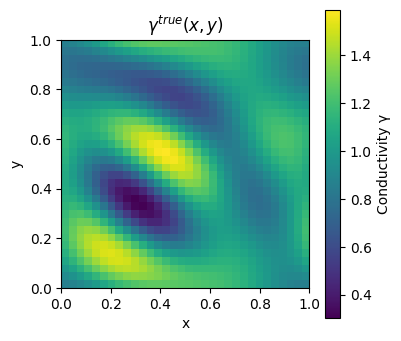

In [10]:
print(gamma_true.shape)


fig = plt.figure(figsize=(4,4))
plt.imshow(gamma_true, origin='lower', extent=[0,1,0,1], cmap="viridis")
plt.colorbar(label="Conductivity γ")
plt.title(r"$\gamma^{true}(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [11]:
f_all.shape

(16, 124)

u_all shape (16, 32, 32)


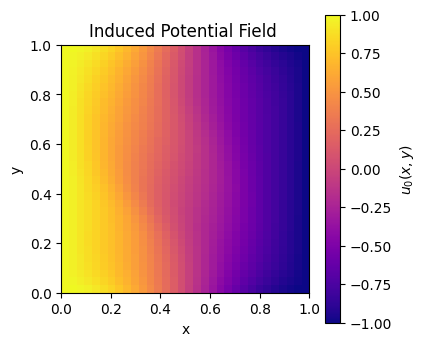

In [12]:
k=0

print('u_all shape', u_all.shape)

u_ex = u_all[k,:,:]

fig = plt.figure(figsize=(4,4))
im1 = plt.imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
plt.title(r"Induced Potential Field ")
plt.xlabel("x")
plt.ylabel("y")
fig.colorbar(im1, label=r'$u_0(x,y)$', orientation='vertical')
plt.show()

(0.0, 127.0)

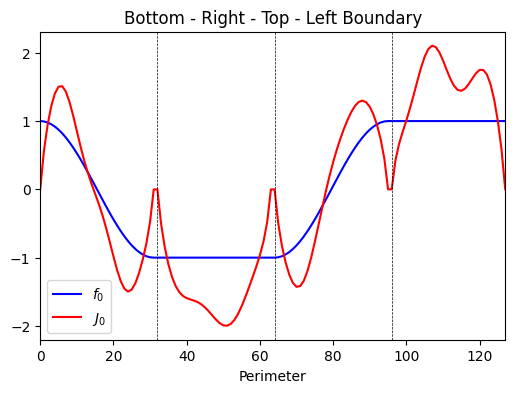

In [13]:
k = 0

######### CHAT GPT ################

x, y = bnd_coords[:,0], bnd_coords[:,1]

# Identify edges
tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

# Sort along each edge
bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# Concatenate perimeter
perimeter_idx = np.concatenate([bottom_idx, right_idx, top_idx, left_idx])

# Reorder f and J consistently
f_true = f_all[k, perimeter_idx]
J_true = J_all[k, perimeter_idx]

afine = np.arange(4*(N))


#################

fig = plt.figure(figsize=(6,4))
plt.plot(afine, f_true, 'b-', label=r"$f_0$")
plt.plot(afine, J_true, 'r-', label=r"$J_0$")
for i in range(1,4):
    plt.axvline(i*N, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Perimeter')
plt.legend()
plt.title('Bottom - Right - Top - Left Boundary')

plt.xlim(left=0, right = 4*N-1)


# fig = plt.figure(figsize=(10,2))
# plt.scatter(left_true[:,1], f_left, color='b', s=20)
# plt.scatter(right_true[:-2,1], f_right[:-2], color='r', s=5)
# # plt.scatter(right_true[-1,1], f_right[-1], color='g', s=5)
# plt.show()

# fig = plt.figure(figsize=(4,4))
# plt.scatter(bottom[:,0], f_bottom, color='g', s=5)
# plt.scatter(top[:,0], f_top, color='m', s=5)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


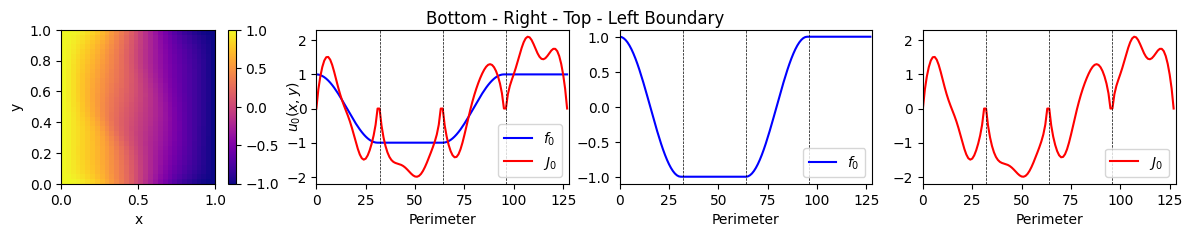

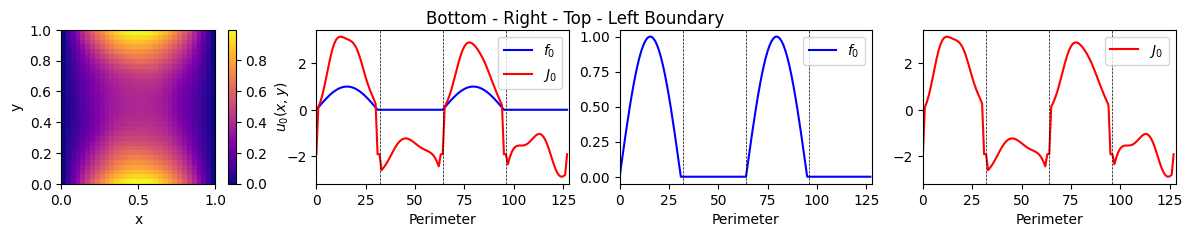

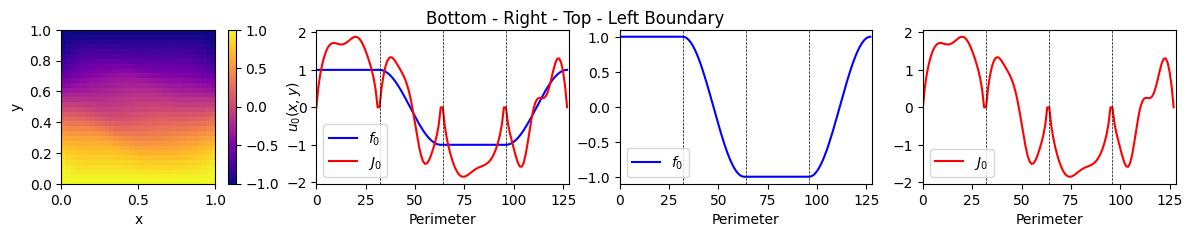

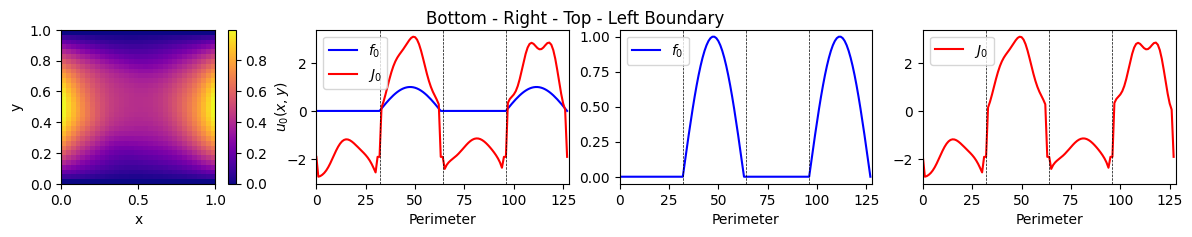

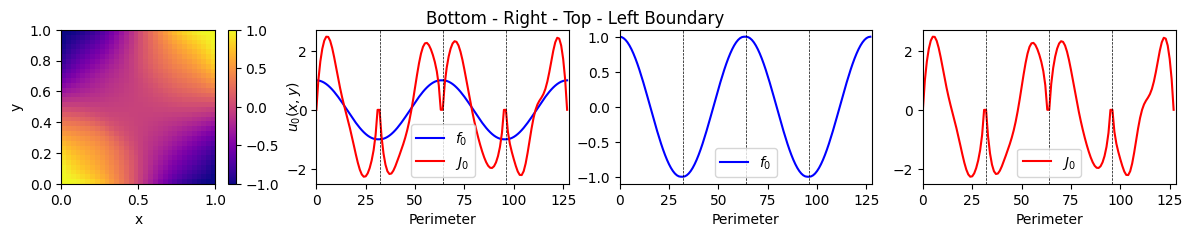

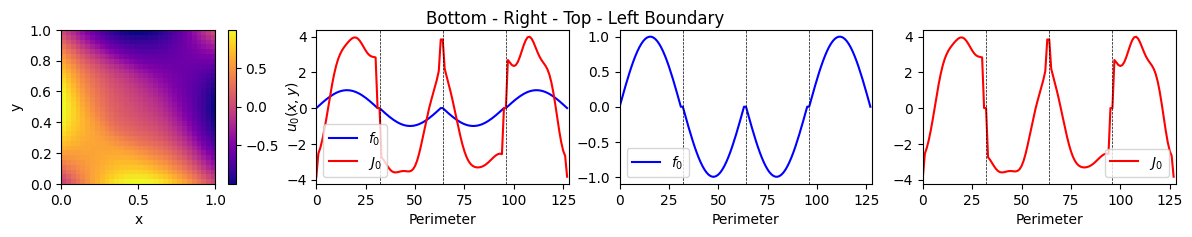

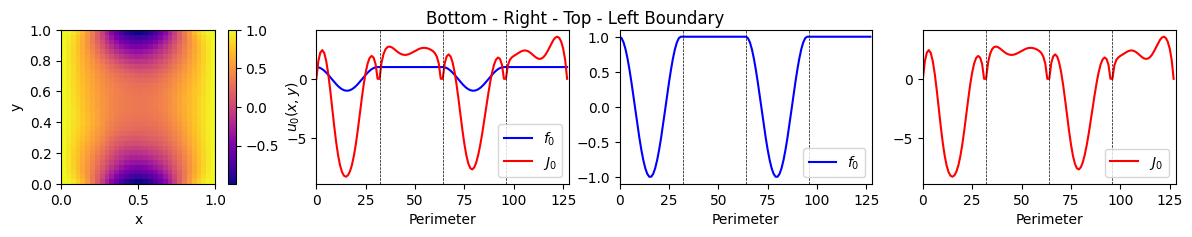

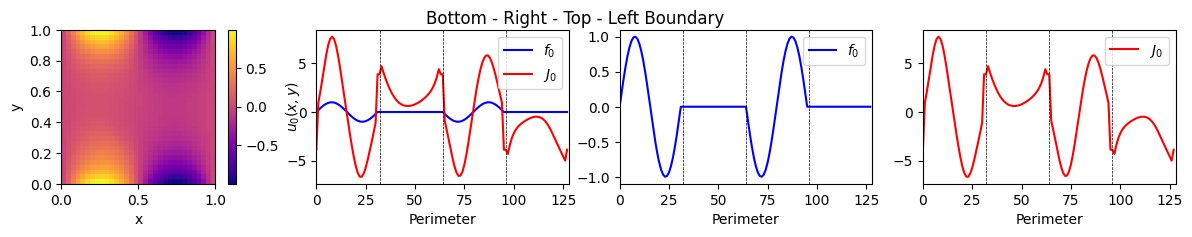

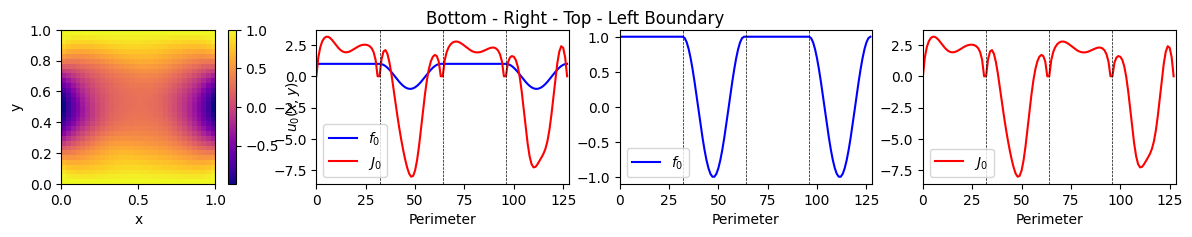

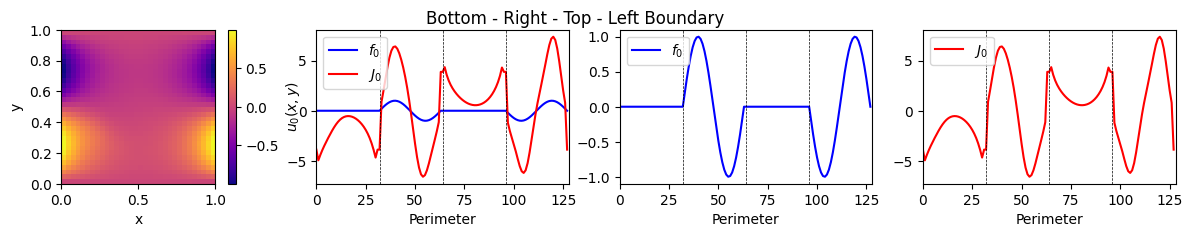

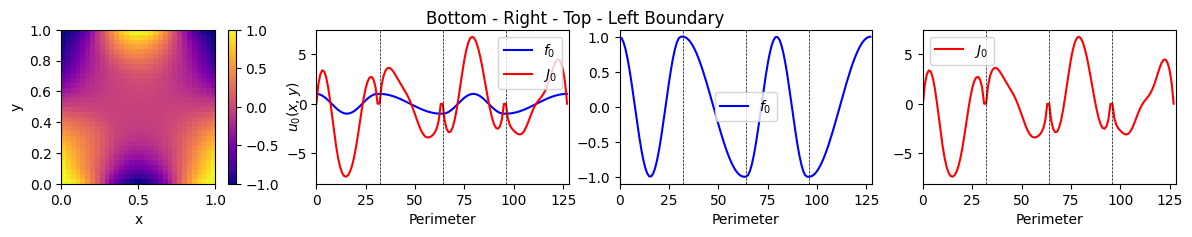

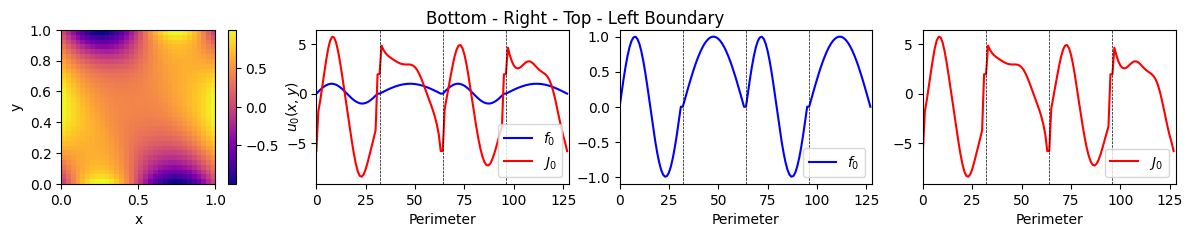

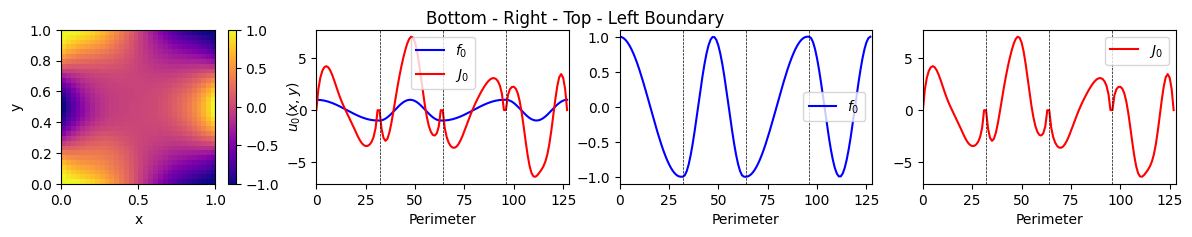

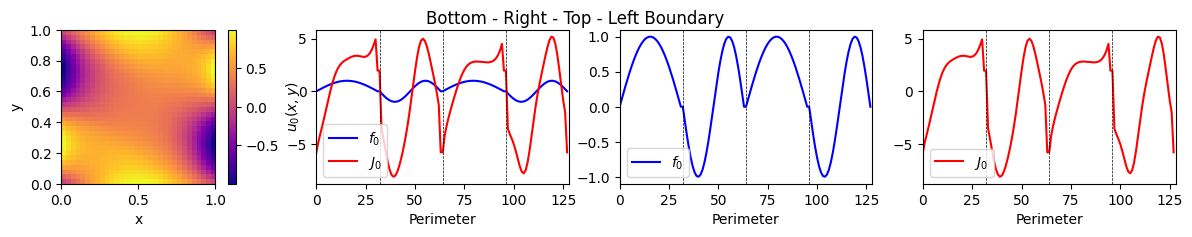

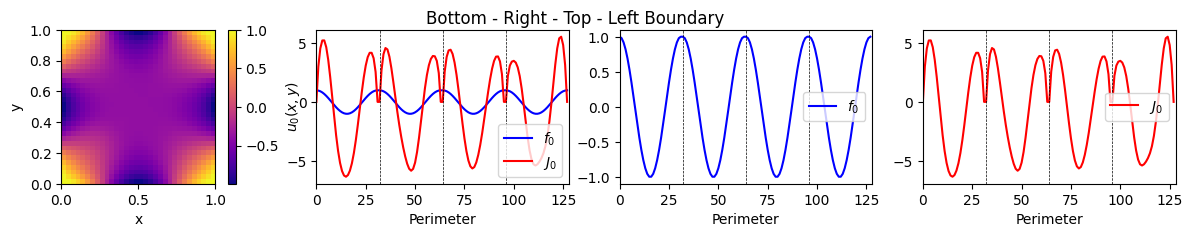

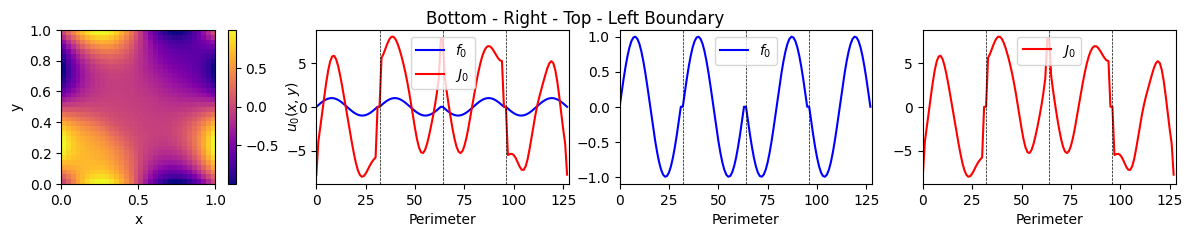

In [14]:
k_list=np.arange(K)
print(k_list)

for k in (k_list):

    f_true = f_all[k, perimeter_idx]
    J_true = J_all[k, perimeter_idx]

    u_ex = u_all[k,:,:]

    fig,ax = plt.subplots(1,4,figsize=(15,2))

    im1 = ax[0].imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    fig.colorbar(im1, ax=ax[0], orientation='vertical', label = r'$u_0(x,y)$')

    ax[1].plot(afine, f_true, 'b-', label=r"$f_0$")
    ax[1].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].set_xlabel('Perimeter')
    ax[1].legend()
    ax[1].set_xlim(left=0, right=4*N)

    ax[2].plot(afine, f_true, 'b-', label=r"$f_0$")
    for i in range(1,4):
        ax[2].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[2].set_xlabel('Perimeter')
    ax[2].legend()
    ax[2].set_xlim(left=0, right=4*N)

    ax[3].plot(afine, J_true, 'r-', label=r"$J_0$")
    for i in range(1,4):
        ax[3].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[3].set_xlabel('Perimeter')
    ax[3].legend()
    ax[3].set_xlim(left=0, right=4*N)
    
    plt.suptitle('Bottom - Right - Top - Left Boundary')

    plt.show()


[ 0.01197605 -0.00598802  0.00898204  0.00449102  0.00299401  0.01197605
  0.02694611  0.01646707  0.09730539  0.1497006   0.05598802 -0.09610778
 -0.20898204  0.03682635 -0.13473054  0.08053892]


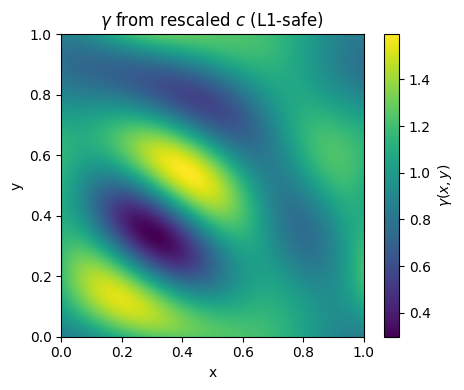

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- paste or import these if not already available ---
def enforce_l1_ball(c_raw, B=None, gamma0=1.0, eps=0.05):
    c_raw = np.asarray(c_raw, float)
    if B is None: B = np.ones_like(c_raw)
    R = gamma0 - eps
    w_l1 = np.sum(B * np.abs(c_raw))
    if w_l1 <= R or R <= 0:  # already safe
        return c_raw.copy()
    return (R / w_l1) * c_raw

def fourier_gamma_on_grid(N, c, k_list, Lx=1.0, Ly=1.0, include_cos=True, include_sin=True, background=1.0):
    x = np.linspace(0, 1, N); y = np.linspace(0, 1, N)
    xx, yy = np.meshgrid(x, y)
    gamma = np.full((N, N), background, float)
    idx = 0
    for (kx, ky) in k_list:
        phase = 2.0*np.pi*(kx*xx/Lx + ky*yy/Ly)
        if include_cos: gamma += c[idx] * np.cos(phase); idx += 1
        if include_sin: gamma += c[idx] * np.sin(phase); idx += 1
    return gamma
# ------------------------------------------------------

# === edit these to match your case ===
N = 201
k_list = [(1,0),(0,1),(1,1),(2,0),(0,2),(2,2),(1,2),(2,1)]
include_cos = True
include_sin = True
background = 1.0
Lx = Ly = 1.0
gamma0, eps = 1.0, 0.05

c_raw = np.array([0.40, -0.20, 0.30, 0.15, 0.10, 0.40, 0.90, 0.55,
                  3.25, 5.00, 1.87, -3.21, -6.98, 1.23, -4.50, 2.69])

# 1) rescale to guarantee positivity (sum|c| <= gamma0 - eps)
c_safe = enforce_l1_ball(c_raw, B=None, gamma0=gamma0, eps=eps)
print(c_safe)

# 2) build gamma from the RESCALED coefficients
gamma_from_c = fourier_gamma_on_grid(
    N, c_safe, k_list, Lx=Lx, Ly=Ly,
    include_cos=include_cos, include_sin=include_sin,
    background=background
)

# 3) plot just this gamma (simple visual check)
plt.figure(figsize=(5,4))
im = plt.imshow(gamma_from_c, origin='lower', extent=[0,1,0,1], cmap='viridis')
plt.colorbar(im, label=r'$\gamma(x,y)$')
plt.title(r'$\gamma$ from rescaled $c$ (L1-safe)')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()


In [22]:
import numpy as np

# assume you already have: fourier_gamma_on_grid(...), c_safe, k_list, etc.
# edit these if needed:
N_check     = 401          # finer grid to be safe
eps         = 0.05
background  = 1.0
Lx = Ly     = 1.0
include_cos = True
include_sin = True

gamma_check = fourier_gamma_on_grid(
    N_check, c_safe, k_list,
    Lx=Lx, Ly=Ly,
    include_cos=include_cos, include_sin=include_sin,
    background=background
)

gmin = float(gamma_check.min())
gmax = float(gamma_check.max())
print(f"γ min={gmin:.6f}, max={gmax:.6f}, expected ≥ {eps}")

# assert positivity (allow tiny FP tolerance)
tol = 1e-12
if gmin < eps - tol:
    # Optional: find how much of the grid violates it
    frac_bad = np.mean(gamma_check < eps)
    raise AssertionError(f"γ violated positivity: min={gmin:.6f} < {eps} (bad fraction {frac_bad:.6%})")
else:
    print("✅ γ is ≥ ε everywhere on the checked grid.")


γ min=0.297897, max=1.592913, expected ≥ 0.05
✅ γ is ≥ ε everywhere on the checked grid.
